In [21]:
import shutil
total, used, free = shutil.disk_usage("/home/jovyan")
print(f"free: {free/1e9:.1f} GB of {total/1e9:.1f} GB")
print("datalad:", shutil.which("datalad"))
print("git-annex:", shutil.which("git-annex"))

free: 286.6 GB of 1073.2 GB
datalad: /srv/conda/envs/notebook/bin/datalad
git-annex: /srv/conda/envs/notebook/bin/git-annex


In [22]:
import pandas as pd

from nilearn import datasets, surface
from nilearn.image import get_data, load_img, new_img_like, index_img, mean_img
from nilearn.maskers import NiftiMasker
from nilearn.plotting import plot_img, plot_stat_map, show, plot_surf_stat_map
from nilearn.decoding.searchlight import search_light
import nilearn.decoding

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.feature_selection import f_classif
from sklearn import neighbors
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


import numpy as np

In [23]:
import pandas as pd
import numpy as np
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_stat_map, show

# ---- paths ----
deriv = "/home/jovyan/hyperface/ds007384/sub-sid000005/ses-1/func"
raw   = "/home/jovyan/hyperface/ds007329/sub-sid000005/ses-1/func"
run   = "run-01"   # define ROIs on run-01, we'll test on run-05 later

bold   = f"{deriv}/sub-sid000005_ses-1_task-localizer_{run}_space-T1w_desc-preproc_bold.nii.gz"
mask   = f"{deriv}/sub-sid000005_ses-1_task-localizer_{run}_space-T1w_desc-brain_mask.nii.gz"
conf_f = f"{deriv}/sub-sid000005_ses-1_task-localizer_{run}_desc-confounds_timeseries.tsv"
ev_f   = f"{raw}/sub-sid000005_ses-1_task-localizer_{run}_events.tsv"

# ---- events: keep only the 5 categories (drop fixation & button_press) ----
events = pd.read_csv(ev_f, sep="\t")
categories = ["faces", "bodies", "objects", "scenes", "scrambled_objects"]
events = events[events["stim_type"].isin(categories)][["onset", "duration", "stim_type"]]
events = events.rename(columns={"stim_type": "trial_type"})   # nilearn expects 'trial_type'
print("events kept:", events["trial_type"].value_counts().to_dict())

# ---- confounds: a few motion regressors (nuisance) ----
conf = pd.read_csv(conf_f, sep="\t")
motion = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
confounds = conf[motion].fillna(0)   # first row of derivatives can be NaN; fill with 0

# ---- fit the GLM ----
glm = FirstLevelModel(
    t_r=1.0,                 # TR = 1s, confirmed from the json
    mask_img=mask,
    high_pass=1/128,         # standard drift removal
    smoothing_fwhm=5,        # light smoothing
)
glm = glm.fit(bold, events=events, confounds=confounds)
print("GLM fit done.")

# ---- contrast: faces > objects  (reveals face-selective cortex -> FFA) ----
z_faces_vs_objects = glm.compute_contrast("faces - objects", output_type="z_score")

# ---- look at it ----
plot_stat_map(z_faces_vs_objects, threshold=3.0,
              title="faces > objects (z), sub-005 run-01",
              display_mode="z", cut_coords=6,
              output_file="/home/jovyan/heather_analysis/figures/6_faces_vs_objects.png")

events kept: {'scrambled_objects': 12, 'faces': 12, 'objects': 12, 'scenes': 12, 'bodies': 12}
GLM fit done.


got a pattern for each of: ['faces', 'bodies', 'objects', 'scenes', 'scrambled_objects']
pattern matrix shape (categories x voxels): (5, 105906)


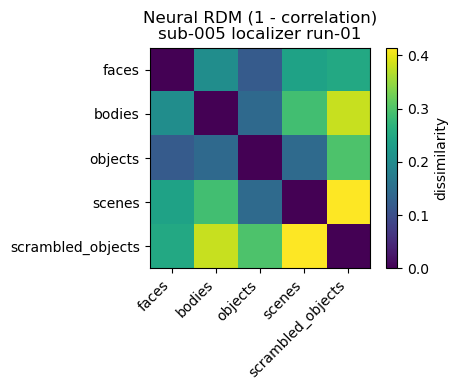


RSA result: neural RDM vs animacy model
Spearman r = -0.213,  p = 0.554
Positive r => brain groups categories by animacy (faces+bodies together).


In [24]:
import numpy as np
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ---- paths (same as before) ----
deriv = "/home/jovyan/hyperface/ds007384/sub-sid000005/ses-1/func"
raw   = "/home/jovyan/hyperface/ds007329/sub-sid000005/ses-1/func"
run   = "run-01"
bold   = f"{deriv}/sub-sid000005_ses-1_task-localizer_{run}_space-T1w_desc-preproc_bold.nii.gz"
mask   = f"{deriv}/sub-sid000005_ses-1_task-localizer_{run}_space-T1w_desc-brain_mask.nii.gz"
conf_f = f"{deriv}/sub-sid000005_ses-1_task-localizer_{run}_desc-confounds_timeseries.tsv"
ev_f   = f"{raw}/sub-sid000005_ses-1_task-localizer_{run}_events.tsv"

# ---- events & confounds (same prep as the GLM cell) ----
categories = ["faces", "bodies", "objects", "scenes", "scrambled_objects"]
events = pd.read_csv(ev_f, sep="\t")
events = events[events["stim_type"].isin(categories)][["onset","duration","stim_type"]]
events = events.rename(columns={"stim_type":"trial_type"})
conf = pd.read_csv(conf_f, sep="\t")
confounds = conf[["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"]].fillna(0)

# ---- fit GLM ----
glm = FirstLevelModel(t_r=1.0, mask_img=mask, high_pass=1/128, smoothing_fwhm=5).fit(
    bold, events=events, confounds=confounds)

# ---- STEP 1: get one pattern (beta map) per category ----
# each category vs baseline -> a whole-brain response pattern for that category
beta_maps = {cat: glm.compute_contrast(cat, output_type="effect_size")
             for cat in categories}
print("got a pattern for each of:", list(beta_maps.keys()))

# ---- STEP 2: pull the patterns into vectors (within the brain mask) ----
masker = NiftiMasker(mask_img=mask).fit()
# rows = categories, columns = voxels
patterns = np.vstack([masker.transform(beta_maps[cat]) for cat in categories])
print("pattern matrix shape (categories x voxels):", patterns.shape)

# ---- STEP 3: build the neural RDM (1 - correlation between category patterns) ----
rdm = squareform(pdist(patterns, metric="correlation"))  # 5x5 dissimilarity matrix

# ---- plot the neural RDM ----
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(rdm, cmap="viridis")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(categories, rotation=45, ha="right"); ax.set_yticklabels(categories)
ax.set_title("Neural RDM (1 - correlation)\nsub-005 localizer run-01")
plt.colorbar(im, label="dissimilarity")
plt.tight_layout(); plt.show()

# ---- STEP 4: compare to an ANIMACY model RDM ----
# prediction: animate (faces, bodies) are similar to each other,
# inanimate (objects, scenes, scrambled) similar to each other,
# animate-vs-inanimate = dissimilar
animate = np.array([1,1,0,0,0])  # faces, bodies animate; rest not
# model dissimilarity = 0 if same animacy, 1 if different
model_rdm = (animate[:,None] != animate[None,:]).astype(float)

# correlate the off-diagonal (upper triangle) of neural vs model RDM
iu = np.triu_indices(5, k=1)
r, p = spearmanr(rdm[iu], model_rdm[iu])
print(f"\nRSA result: neural RDM vs animacy model")
print(f"Spearman r = {r:.3f},  p = {p:.3f}")
print("Positive r => brain groups categories by animacy (faces+bodies together).")

visual ROI voxels: 12233  (was 105906 for whole brain)
pattern matrix (categories x ROI voxels): (5, 12233)


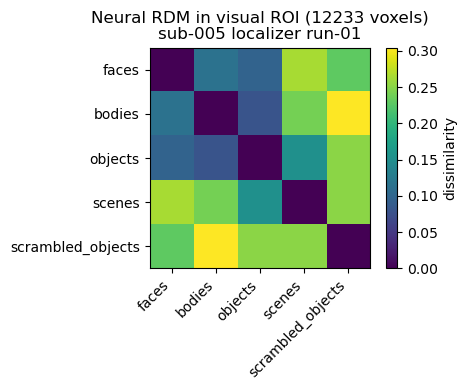


Animacy RSA (visual ROI): Spearman r = 0.000, p = 1.000

Pairwise dissimilarities (lower = more similar):
  faces              vs bodies            : 0.115
  faces              vs objects           : 0.097
  faces              vs scenes            : 0.265
  faces              vs scrambled_objects : 0.229
  bodies             vs objects           : 0.079
  bodies             vs scenes            : 0.240
  bodies             vs scrambled_objects : 0.304
  objects            vs scenes            : 0.153
  objects            vs scrambled_objects : 0.251
  scenes             vs scrambled_objects : 0.251


In [25]:
import numpy as np
from nilearn.image import math_img
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

categories = ["faces", "bodies", "objects", "scenes", "scrambled_objects"]

# ---- STEP 1: define a VISUAL-CORTEX ROI from the GLM itself ----
# "all categories > baseline" finds voxels that respond to visual stimulation.
# We average the 5 category-vs-baseline contrasts into one "visual response" map.
visual_z = glm.compute_contrast(
    "0.2*faces + 0.2*bodies + 0.2*objects + 0.2*scenes + 0.2*scrambled_objects",
    output_type="z_score")

# threshold it to keep only strongly visually-responsive voxels -> ROI mask
roi_mask = math_img("img > 3.1", img=visual_z)   # z > 3.1 ~ p<0.001
n_vox = int(roi_mask.get_fdata().sum())
print(f"visual ROI voxels: {n_vox}  (was 105906 for whole brain)")

# ---- STEP 2: extract the 5 category patterns WITHIN this ROI ----
beta_maps = {c: glm.compute_contrast(c, output_type="effect_size") for c in categories}
masker = NiftiMasker(mask_img=roi_mask).fit()
patterns = np.vstack([masker.transform(beta_maps[c]) for c in categories])
print("pattern matrix (categories x ROI voxels):", patterns.shape)

# ---- STEP 3: neural RDM within visual cortex ----
rdm = squareform(pdist(patterns, metric="correlation"))

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(rdm, cmap="viridis")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(categories, rotation=45, ha="right"); ax.set_yticklabels(categories)
ax.set_title(f"Neural RDM in visual ROI ({n_vox} voxels)\nsub-005 localizer run-01")
plt.colorbar(im, label="dissimilarity")
plt.tight_layout(); plt.show()

# ---- STEP 4: test the animacy model again ----
animate = np.array([1,1,0,0,0])          # faces, bodies = animate
model_rdm = (animate[:,None] != animate[None,:]).astype(float)
iu = np.triu_indices(5, k=1)
r, p = spearmanr(rdm[iu], model_rdm[iu])
print(f"\nAnimacy RSA (visual ROI): Spearman r = {r:.3f}, p = {p:.3f}")

# ---- also just look at the numbers plainly ----
print("\nPairwise dissimilarities (lower = more similar):")
for i in range(5):
    for j in range(i+1,5):
        print(f"  {categories[i]:18s} vs {categories[j]:18s}: {rdm[i,j]:.3f}")

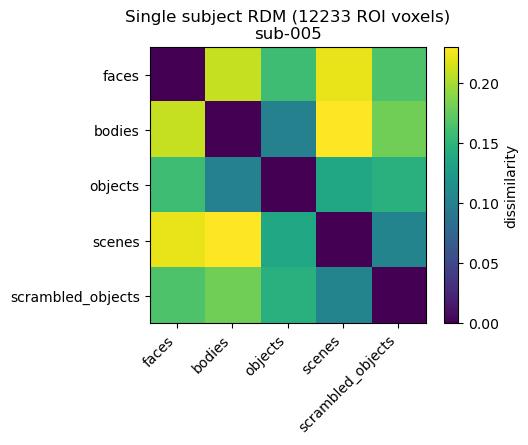

saved, ROI voxels: 12233


In [31]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import math_img
from nilearn.maskers import NiftiMasker
from scipy.spatial.distance import pdist, squareform

DERIV = "/home/jovyan/hyperface/ds007384"
RAW   = "/home/jovyan/hyperface/ds007329"
FIG   = "/home/jovyan/heather_analysis/figures"
categories = ["faces","bodies","objects","scenes","scrambled_objects"]
motion = ["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"]
sub = "sub-sid000005"

def fit(run):
    d = f"{DERIV}/{sub}/ses-1/func"; r = f"{RAW}/{sub}/ses-1/func"
    base = f"{sub}_ses-1_task-localizer_{run}"
    ev = pd.read_csv(f"{r}/{base}_events.tsv", sep="\t")
    ev = ev[ev["stim_type"].isin(categories)][["onset","duration","stim_type"]].rename(
        columns={"stim_type":"trial_type"})
    conf = pd.read_csv(f"{d}/{base}_desc-confounds_timeseries.tsv", sep="\t")[motion].fillna(0)
    g = FirstLevelModel(t_r=1.0, mask_img=f"{d}/{base}_space-T1w_desc-brain_mask.nii.gz",
                        high_pass=1/128, smoothing_fwhm=5)
    return g.fit(f"{d}/{base}_space-T1w_desc-preproc_bold.nii.gz", events=ev, confounds=conf)

glm1 = fit("run-01")
roi = math_img("img > 3.1", img=glm1.compute_contrast(
    "0.2*faces+0.2*bodies+0.2*objects+0.2*scenes+0.2*scrambled_objects", output_type="z_score"))
nvox = int(roi.get_fdata().sum())

glm5 = fit("run-05")
masker = NiftiMasker(mask_img=roi).fit()
pats = np.vstack([masker.transform(glm5.compute_contrast(c, output_type="effect_size"))
                  for c in categories])
rdm = squareform(pdist(pats, metric="correlation"))

fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(rdm, cmap="viridis")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(categories, rotation=45, ha="right"); ax.set_yticklabels(categories)
ax.set_title(f"Single subject RDM ({nvox} ROI voxels)\nsub-005")
plt.colorbar(im, label="dissimilarity")
plt.tight_layout()
plt.savefig(f"{FIG}/7_single_subject_rdm.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved, ROI voxels:", nvox)

stacked RDMs: (21, 5, 5)


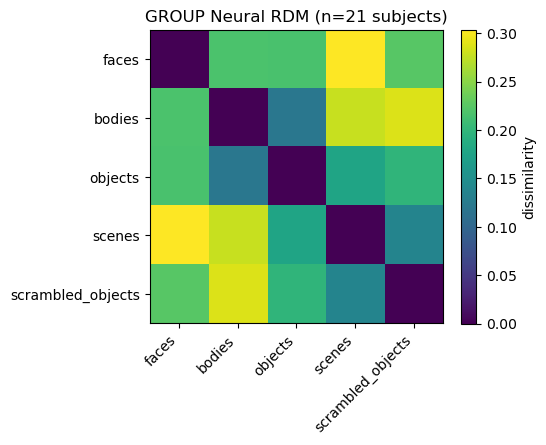


Animacy correlation per subject (n=21):
  mean r = 0.325  (range -0.07 to 0.64)
  one-sample t-test vs 0:  t = 6.42,  p = 0.0000
  -> if p < 0.05 and mean r > 0: animacy structure is reliable across people

GROUP pairwise dissimilarities (low = similar):
  bodies             vs objects           : 0.120
  scenes             vs scrambled_objects : 0.137
  objects            vs scenes            : 0.177
  objects            vs scrambled_objects : 0.199
  faces              vs objects           : 0.216
  faces              vs bodies            : 0.218
  faces              vs scrambled_objects : 0.225
  bodies             vs scenes            : 0.279
  bodies             vs scrambled_objects : 0.288
  faces              vs scenes            : 0.303


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp

categories = ["faces","bodies","objects","scenes","scrambled_objects"]

# load the saved per-subject RDMs
rdms = np.load("/home/jovyan/heather_analysis/hyperface_rdms.npy", allow_pickle=True).item()
subs = sorted(rdms.keys())
all_rdms = np.stack([rdms[s] for s in subs])   # shape: 21 x 5 x 5
print("stacked RDMs:", all_rdms.shape)

# ---- GROUP RDM: average across the 21 subjects ----
group_rdm = all_rdms.mean(axis=0)

fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(group_rdm, cmap="viridis")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(categories, rotation=45, ha="right"); ax.set_yticklabels(categories)
ax.set_title(f"GROUP Neural RDM (n={len(subs)} subjects)")
plt.colorbar(im, label="dissimilarity"); plt.tight_layout(); plt.show()

# ---- ANIMACY TEST across subjects ----
animate = np.array([1,1,0,0,0])
model_rdm = (animate[:,None] != animate[None,:]).astype(float)
iu = np.triu_indices(5, k=1)

# animacy correlation for EACH subject
per_sub_r = np.array([spearmanr(rdms[s][iu], model_rdm[iu]).statistic for s in subs])
t, p = ttest_1samp(per_sub_r, 0)   # is the group's animacy correlation above zero?

print(f"\nAnimacy correlation per subject (n={len(subs)}):")
print(f"  mean r = {per_sub_r.mean():.3f}  (range {per_sub_r.min():.2f} to {per_sub_r.max():.2f})")
print(f"  one-sample t-test vs 0:  t = {t:.2f},  p = {p:.4f}")
print("  -> if p < 0.05 and mean r > 0: animacy structure is reliable across people")

# ---- group pairwise numbers, sorted ----
print("\nGROUP pairwise dissimilarities (low = similar):")
pairs = [(categories[i], categories[j], group_rdm[i,j])
         for i in range(5) for j in range(i+1,5)]
for a,b,v in sorted(pairs, key=lambda x:x[2]):
    print(f"  {a:18s} vs {b:18s}: {v:.3f}")

Model                    mean r        t           p
----------------------------------------------------
Animacy                   0.325     6.42    2.93e-06
Face-selective            0.230     3.65    1.58e-03
Object vs scene           0.437     7.05    7.70e-07
Intact vs scrambled      -0.017    -0.42    6.80e-01


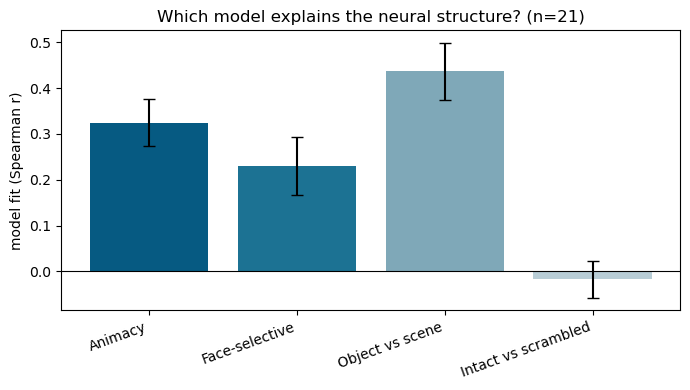

/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


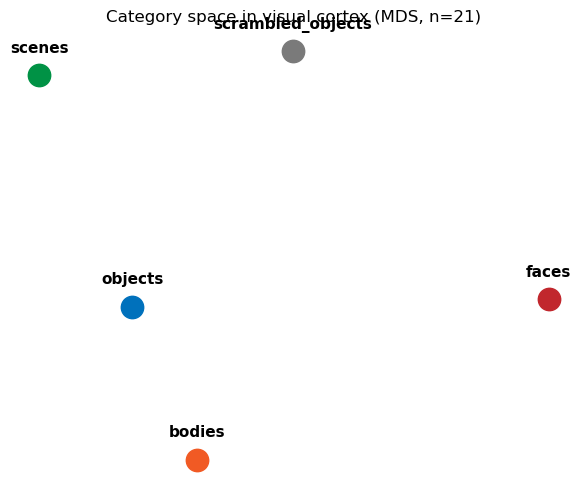

In [28]:
#animacy accounts for 0.325 of variance; now test other models 

import numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp
from scipy.spatial.distance import squareform
from sklearn.manifold import MDS

categories = ["faces","bodies","objects","scenes","scrambled_objects"]
rdms = np.load("/home/jovyan/heather_analysis/hyperface_rdms.npy", allow_pickle=True).item()
subs = sorted(rdms.keys())
iu = np.triu_indices(5, k=1)

# ---------- define competing models ----------
def model_from_groups(groups):
    """groups: list of group-labels per category. 0 dissimilarity within group, 1 between."""
    g = np.array(groups)
    return (g[:,None] != g[None,:]).astype(float)

models = {
    # faces, bodies animate; objects, scenes, scrambled inanimate
    "Animacy":            model_from_groups([1,1,0,0,0]),
    # faces special, everything else lumped
    "Face-selective":     model_from_groups([1,0,0,0,0]),
    # discrete single objects vs complex/degraded images
    "Object vs scene":    model_from_groups([0,0,0,1,1]),
    # intact images vs scrambled (a low-level visual control)
    "Intact vs scrambled":model_from_groups([0,0,0,0,1]),
}

# ---------- test each model across the 21 subjects ----------
print(f"{'Model':<22}{'mean r':>9}{'t':>9}{'p':>12}")
print("-"*52)
results = {}
for name, m in models.items():
    rs = np.array([spearmanr(rdms[s][iu], m[iu]).statistic for s in subs])
    t, p = ttest_1samp(rs, 0)
    results[name] = (rs, rs.mean(), t, p)
    print(f"{name:<22}{rs.mean():>9.3f}{t:>9.2f}{p:>12.2e}")

# ---------- bar plot of model fits with error bars ----------
fig, ax = plt.subplots(figsize=(7,4))
names = list(results.keys())
means = [results[n][1] for n in names]
sems  = [results[n][0].std(ddof=1)/np.sqrt(len(subs)) for n in names]
bars = ax.bar(names, means, yerr=sems, capsize=4,
              color=["#065A82","#1C7293","#7FA8B8","#B8CDD6"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("model fit (Spearman r)")
ax.set_title(f"Which model explains the neural structure? (n={len(subs)})")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

# ---------- MDS: the categories arranged in "brain space" ----------
group_rdm = np.stack([rdms[s] for s in subs]).mean(axis=0)
coords = MDS(n_components=2, dissimilarity="precomputed",
             random_state=0, normalized_stress="auto").fit_transform(group_rdm)

fig, ax = plt.subplots(figsize=(6,5))
colors = {"faces":"#C1272D","bodies":"#F15A24","objects":"#0071BC",
          "scenes":"#009245","scrambled_objects":"#7A7A7A"}
for (x,y), cat in zip(coords, categories):
    ax.scatter(x, y, s=260, color=colors[cat], zorder=3)
    ax.annotate(cat, (x,y), textcoords="offset points", xytext=(0,16),
                ha="center", fontsize=11, weight="bold")
ax.set_title(f"Category space in visual cortex (MDS, n={len(subs)})")
ax.set_xticks([]); ax.set_yticks([])
ax.spines[["top","right","left","bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

In [3]:
!find ~/hyperface -iname "*stimul*" -o -iname "*rating*" -o -iname "*rdm*" 2>/dev/null | head -30
!ls ~/hyperface/ds007329/derivatives/
!head -5 ~/hyperface/ds007329/sub-sid000005/ses-1/func/sub-sid000005_ses-1_task-visualmemory_run-02_events.tsv

561.54s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/home/jovyan/hyperface/ds007329/derivatives/qa/stimuli
/home/jovyan/hyperface/ds007329/derivatives/stimuli
/home/jovyan/hyperface/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insightface_embeddings_rdms__plus0.npy
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insightface_embeddings_rdms__plus1.npy
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insightface_embeddings_rdms__plus10.npy
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insightface_embeddings_rdms__plus11.npy
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insightface_embeddings_rdms__plus12.npy
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insightface_embeddings_rdms__plus13.npy
/home/jovyan/hyperface/ds007329/derivatives/stimuli/rdms/dnn/insightface/insig

570.83s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


fmriprep  freesurfer  jiahui-2023  qa  README.md  stimuli


576.03s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


onset	duration	trial_type
0.001	10.000	fixation
10.024	4.000	face207.mp4
14.050	4.000	face412.mp4
18.057	4.000	face034.mp4


In [4]:
!head -5 ~/hyperface/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv
!wc -l ~/hyperface/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv
!ls ~/hyperface/ds007329/derivatives/stimuli/
!ls ~/hyperface/ds007329/derivatives/stimuli/labels/
!ls ~/hyperface/ds007329/derivatives/stimuli/rdms/
!cat ~/hyperface/ds007329/derivatives/README.md 2>/dev/null | head -40

910.97s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


head: cannot open '/home/jovyan/hyperface/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv' for reading: No such file or directory


916.17s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


wc: /home/jovyan/hyperface/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv: No such file or directory


921.38s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


...

behavioral-ratings.tsv


931.78s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


behavioral-arrangement	dnn


936.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


# HyperFace Derivatives

## Directory Structure

```
derivatives/
├── fmriprep/           # Current preprocessing (fMRIPrep 25.1.4)
├── freesurfer/         # FreeSurfer outputs (from fMRIPrep 25.1.4)
├── qa/                 # Quality assurance analyses
├── stimuli/            # Stimulus descriptors (embeddings, RDMs)
└── jiahui-2023/        # Data from Jiahui et al. (2023) PNAS
```

## Contents

### fmriprep/
Preprocessed fMRI data using fMRIPrep 25.1.4 for the data paper.

### freesurfer/
FreeSurfer outputs for all subjects, including recon-all results. Generated by fMRIPrep 25.1.4.

### qa/
Quality assurance analyses for the data paper.

### stimuli/
Computational and behavioral descriptors of the 707 video clips (4s each):
- `labels/behavioral-ratings.tsv` - MTurk consensus ratings (gender, age, ethnicity, emotion, head direction)
- `embeddings/insightface/` - Raw layer activations from InsightFace (707 files)
- `rdms/behavioral-arrangement/` - Behavioral arrangement task RDMs (12 r

In [29]:
import numpy as np, pandas as pd

base = "/home/jovyan/hyperface/ds007329/derivatives/stimuli"

# behavioral arrangement RDMs
for i in ["00","01"]:
    r = np.load(f"{base}/rdms/behavioral-arrangement/{i}.npy")
    print(f"run {i}: shape {r.shape}, dtype {r.dtype}, "
          f"range {np.nanmin(r):.3f}-{np.nanmax(r):.3f}, "
          f"diag mean {np.nanmean(np.diag(r)):.3f}")

# behavioral ratings
rat = pd.read_csv(f"{base}/labels/behavioral-ratings.tsv", sep="\t")
print("\nratings shape:", rat.shape)
print(rat.head())
print("\ncolumns:", list(rat.columns))

# the stimuli README explains the format - worth reading
print(open(f"{base}/README.md").read()[:2000])

run 00: shape (10, 1711), dtype float64, range 17.000-638.565, diag mean 225.470
run 01: shape (11, 1711), dtype float64, range 10.050-652.694, diag mean 263.967

ratings shape: (707, 7)
                     clip  gender    age                  ethnicity  \
0  1U9n2Z68-A0_000028.mp4    Male  31-40                      White   
1  1U9n2Z68-A0_000049.mp4    Male  21-30                      White   
2  1U9n2Z68-A0_000110.mp4    Male  21-30         Hispanic or Latino   
3  1U9n2Z68-A0_000130.mp4  Female  21-30  Black or African American   
4  1U9n2Z68-A0_000140.mp4  Female  21-30  Black or African American   

     emotion      npeople       headdir  
0    Neutral  more than 2  Mostly Right  
1    Neutral            1  Mostly Right  
2    Neutral            1  Mostly Right  
3    Neutral            1  Mostly Right  
4  Happiness  more than 2  Mostly Right  

columns: ['clip', 'gender', 'age', 'ethnicity', 'emotion', 'npeople', 'headdir']
# Stimulus Descriptors

This directory contains comp

In [7]:
txt = open("/home/jovyan/hyperface/ds007329/derivatives/stimuli/README.md").read()
i = txt.find("behavioral-arrangement")
print(txt[i-200:i+2500])

rprise, Anger, Disgust, Sadness, Fear |
| `npeople` | Number of people visible | 1, 2, more than 2 |
| `headdir` | Overall head orientation | Mostly Left, Mostly Center, Mostly Right |

---

### rdms/behavioral-arrangement/
**Representational Dissimilarity Matrices from online behavioral arrangement task**

- **Files**: 12 `.npy` files (`00.npy` to `11.npy`), one per experimental run
- **Shape**: `(n_participants, n_pairs)` where:
  - `n_participants`: 10-12 participants per run
  - `n_pairs`: 1711 (upper triangle of 59x59 matrix) for runs 00-10; 1653 (58x58) for run 11
- **Dtype**: float64
- **Values**: Pairwise distances from arrangement task (higher = more dissimilar)

Each run presented a ~59 stimuli to participants. The 12 runs together cover all 707 clips.

---

### rdms/dnn/
**RDMs computed from DNN layer activations**

All RDMs are stored as flattened upper triangles of 707x707 similarity matrices.
- **Shape**: `(249571,)` = 707 * 706 / 2 unique pairs
- **Dtype**: float64

####

In [30]:
import pandas as pd
ev = pd.read_csv("/home/jovyan/hyperface/ds007329/sub-sid000005/ses-1/func/"
                 "sub-sid000005_ses-1_task-visualmemory_run-02_events.tsv", sep="\t")
clips = ev[ev.trial_type.str.endswith(".mp4")]
print(len(clips), "clip trials;", clips.trial_type.nunique(), "unique")
print(clips.trial_type.head(10).tolist())

63 clip trials; 63 unique
['face207.mp4', 'face412.mp4', 'face034.mp4', '1U9n2Z68-A0_000049.mp4', 'w4QYKImkBUA_000227.mp4', 'face072.mp4', 'face132.mp4', 'face246.mp4', 'IMUGKHYRhSA_000051.mp4', 'WxCKGACDHNg_000108.mp4']


In [9]:
import pandas as pd, numpy as np

ev = pd.read_csv("/home/jovyan/hyperface/ds007329/sub-sid000005/ses-1/func/"
                 "sub-sid000005_ses-1_task-visualmemory_run-02_events.tsv", sep="\t")
print(ev.trial_type.value_counts().head(10))   # any repeated clips?
print("\nall rows:")
print(ev.to_string())   # see the full structure incl. fixation / gaps

trial_type
button_press_1            3
fixation                  3
button_press_2            2
face334.mp4               1
face371.mp4               1
face379.mp4               1
face149.mp4               1
USIPTs4SKzU_000123.mp4    1
phmu0xneeQE_000332.mp4    1
face059.mp4               1
Name: count, dtype: int64

all rows:
      onset  duration                    trial_type
0     0.001      10.0                      fixation
1    10.024       4.0                   face207.mp4
2    14.050       4.0                   face412.mp4
3    18.057       4.0                   face034.mp4
4    22.069       4.0        1U9n2Z68-A0_000049.mp4
5    26.081       4.0        w4QYKImkBUA_000227.mp4
6    30.093       4.0                   face072.mp4
7    34.106       4.0                   face132.mp4
8    38.117       4.0                   face246.mp4
9    42.130       4.0        IMUGKHYRhSA_000051.mp4
10   46.142       4.0        WxCKGACDHNg_000108.mp4
11   50.154       4.0        IuJe2mk4Smo_000105.

In [10]:
!find ~/hyperface/ds007329 -iname "*.tsv" -path "*stimuli*" 2>/dev/null
!ls ~/hyperface/ds007329/stimuli/ 2>/dev/null | head
!find ~/hyperface/ds007329 -iname "*block*" -o -iname "*order*" -o -iname "*clip*list*" 2>/dev/null | head

2147.00s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/home/jovyan/hyperface/ds007329/derivatives/stimuli/labels/behavioral-ratings.tsv


2152.57s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
2157.73s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/home/jovyan/hyperface/ds007329/derivatives/jiahui-2023/fmriprep-1.4.1/sub-sid000005_ses-1_task-visualmemory_run-02_space-fsaverage-icoorder5_hemi-L.func.npy
/home/jovyan/hyperface/ds007329/derivatives/jiahui-2023/fmriprep-1.4.1/sub-sid000005_ses-1_task-visualmemory_run-02_space-fsaverage-icoorder5_hemi-R.func.npy
/home/jovyan/hyperface/ds007329/derivatives/jiahui-2023/fmriprep-1.4.1/sub-sid000005_ses-1_task-visualmemory_run-03_space-fsaverage-icoorder5_hemi-L.func.npy
/home/jovyan/hyperface/ds007329/derivatives/jiahui-2023/fmriprep-1.4.1/sub-sid000005_ses-1_task-visualmemory_run-03_space-fsaverage-icoorder5_hemi-R.func.npy
/home/jovyan/hyperface/ds007329/derivatives/jiahui-2023/fmriprep-1.4.1/sub-sid000005_ses-1_task-visualmemory_run-04_space-fsaverage-icoorder5_hemi-L.func.npy
/home/jovyan/hyperface/ds007329/derivatives/jiahui-2023/fmriprep-1.4.1/sub-sid000005_ses-1_task-visualmemory_run-04_space-fsaverage-icoorder5_hemi-R.func.npy
/home/jovyan/hyperface/ds007329/derivatives/jiahui-2

In [11]:
import pandas as pd
def clips(sub, run):
    p = f"/home/jovyan/hyperface/ds007329/{sub}/ses-1/func/{sub}_ses-1_task-visualmemory_{run}_events.tsv"
    e = pd.read_csv(p, sep="\t")
    return set(e[e.trial_type.str.endswith(".mp4")].trial_type)
a, b = clips("sub-sid000005","run-02"), clips("sub-sid000007","run-02")
print(len(a), len(b), "shared:", len(a & b))

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/hyperface/ds007329/sub-sid000007/ses-1/func/sub-sid000007_ses-1_task-visualmemory_run-02_events.tsv'

In [12]:
main = ev[ev.trial_type.str.endswith(".mp4") & ~ev.trial_type.str.startswith("catch_")]
print(len(main), "main clips")

59 main clips


In [14]:
import pandas as pd, itertools

def clips(sub, run, ses="ses-1"):
    p = (f"/home/jovyan/hyperface/ds007329/{sub}/{ses}/func/"
         f"{sub}_{ses}_task-visualmemory_{run}_events.tsv")
    e = pd.read_csv(p, sep="\t")
    m = e[e.trial_type.str.endswith(".mp4") & ~e.trial_type.str.startswith("catch_")]
    return list(m.trial_type)

runs = ["run-02","run-03","run-04","run-06","run-07","run-08"]

# 1. Do two subjects' run-02 contain the same clip SET?
a = set(clips("sub-sid000005","run-02"))
b = set(clips("sub-sid000007","run-02"))
print(f"sub-005 run-02: {len(a)} clips | sub-007 run-02: {len(b)} | shared: {len(a & b)}")

# 2. If not, does sub-007 have a DIFFERENT run matching sub-005's run-02?
print("\nsub-005 run-02 vs each sub-007 run:")
for r in runs:
    try:
        o = len(a & set(clips("sub-sid000007", r)))
        print(f"  {r}: {o} shared")
    except FileNotFoundError:
        print(f"  {r}: not downloaded")

# 3. Same clips in the same ORDER, or shuffled?
if len(a & b) > 50:
    print("\nfirst 5 of each (order check):")
    print("  sub-005:", clips("sub-sid000005","run-02")[:5])
    print("  sub-007:", clips("sub-sid000007","run-02")[:5])

sub-005 run-02: 59 clips | sub-007 run-02: 59 | shared: 0

sub-005 run-02 vs each sub-007 run:
  run-02: 0 shared
  run-03: 0 shared
  run-04: 0 shared
  run-06: 0 shared
  run-07: 59 shared
  run-08: 0 shared


In [15]:
import pandas as pd, numpy as np, os
from collections import defaultdict

RAW = "/home/jovyan/hyperface/ds007329"
runs_by_ses = {"ses-1": ["run-02","run-03","run-04","run-06","run-07","run-08"],
               "ses-2": ["run-02","run-03","run-04","run-06","run-07","run-08"]}

def clips(sub, ses, run):
    p = f"{RAW}/{sub}/{ses}/func/{sub}_{ses}_task-visualmemory_{run}_events.tsv"
    e = pd.read_csv(p, sep="\t")
    m = e[e.trial_type.str.endswith(".mp4") & ~e.trial_type.str.startswith("catch_")]
    return list(m.trial_type)

subs = sorted(d for d in os.listdir(RAW) if d.startswith("sub-"))
blocks = defaultdict(list)      # frozenset(clips) -> [(sub, ses, run), ...]
missing = []
for sub in subs:
    for ses, rl in runs_by_ses.items():
        for run in rl:
            try:
                c = clips(sub, ses, run)
                blocks[frozenset(c)].append((sub, ses, run, tuple(c)))
            except FileNotFoundError:
                missing.append((sub, ses, run))

print(f"distinct blocks found: {len(blocks)}   (expect 12)")
print(f"runs not downloaded: {len(missing)}")
for i, (k, v) in enumerate(blocks.items()):
    print(f"  block {i}: {len(k)} clips, seen in {len(v)} runs")

distinct blocks found: 12   (expect 12)
runs not downloaded: 234
  block 0: 59 clips, seen in 2 runs
  block 1: 59 clips, seen in 2 runs
  block 2: 59 clips, seen in 2 runs
  block 3: 59 clips, seen in 2 runs
  block 4: 59 clips, seen in 2 runs
  block 5: 59 clips, seen in 2 runs
  block 6: 58 clips, seen in 1 runs
  block 7: 59 clips, seen in 1 runs
  block 8: 59 clips, seen in 1 runs
  block 9: 59 clips, seen in 1 runs
  block 10: 59 clips, seen in 1 runs
  block 11: 59 clips, seen in 1 runs


In [19]:
pos = {c:i for i,c in enumerate(canonical)}
for bi in range(12):
    B = behav_rdm(bi); n = B.shape[0]
    iu = np.triu_indices(n,1)
    for k in blocks:
        if len(k) != n: continue
        for name, order in [("alpha", sorted(k)),
                            ("alpha_rev", sorted(k, reverse=True))]:
            idx = [pos[c] for c in order]
            sub = dnn[np.ix_(idx,idx)]
            rho = spearmanr(B[iu], sub[iu]).statistic
            if rho > 0.15:
                print(f"HIT behav {bi} {name}: rho={rho:.3f}")

In [20]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

STIM = f"{RAW}/derivatives/stimuli"
ratings = pd.read_csv(f"{STIM}/labels/behavioral-ratings.tsv", sep="\t")
canonical = list(ratings["clip"])          # candidate canonical 707 order
print("canonical list:", len(canonical))

# full 707x707 DNN RDM (ground truth structure)
dnn = squareform(np.load(f"{STIM}/rdms/dnn/insightface/insightface_embeddings_rdms_fc1.npy"))
print("DNN RDM:", dnn.shape)

# identify the 58-clip block -> must be 11.npy
sizes = {len(k): k for k in blocks}
print("block sizes present:", sorted(set(len(k) for k in blocks)))

def behav_rdm(idx):
    arr = np.load(f"{STIM}/rdms/behavioral-arrangement/{idx:02d}.npy")
    return squareform(arr.mean(axis=0))     # average across raters -> square

# test: for each behavioural RDM, try each block under the canonical ordering
print(f"\n{'behav':>6} {'block':>6} {'n':>4} {'rho vs DNN':>12}")
for bi in range(12):
    B = behav_rdm(bi)
    n = B.shape[0]
    best = (None, -9)
    for k in blocks:
        if len(k) != n:
            continue
        # order this block's clips by position in the canonical list
        order = [c for c in canonical if c in k]
        if len(order) != n:
            continue
        idx = [canonical.index(c) for c in order]
        sub_dnn = dnn[np.ix_(idx, idx)]
        iu = np.triu_indices(n, 1)
        rho = spearmanr(B[iu], sub_dnn[iu]).statistic
        if rho > best[1]:
            best = (k, rho)
    print(f"{bi:>6} {'match':>6} {n:>4} {best[1]:>12.3f}")

canonical list: 707
DNN RDM: (707, 707)
block sizes present: [58, 59]

 behav  block    n   rho vs DNN
     0  match   59        0.028
     1  match   59        0.013
     2  match   59        0.033
     3  match   59        0.030
     4  match   59        0.061
     5  match   59        0.044
     6  match   59        0.038
     7  match   59        0.033
     8  match   59        0.051
     9  match   59        0.017
    10  match   59        0.027
    11  match   58        0.007


In [21]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

STIM = "/home/jovyan/hyperface/ds007329/derivatives/stimuli"
dnn_full = np.load(f"{STIM}/rdms/dnn/insightface/insightface_embeddings_rdms_fc1.npy")

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    s = slice(run*59, (run+1)*59)
    return squareform(m[s][:, s])

for run in range(12):
    b = np.load(f"{STIM}/rdms/behavioral-arrangement/{run:02d}.npy").mean(axis=0)
    d = single_run(dnn_full, run)
    if len(b) != len(d):
        print(f"run {run}: length mismatch {len(b)} vs {len(d)}"); continue
    r, p = pearsonr(b, d)
    print(f"run {run:2d}: r = {r:.3f}")

run  0: r = 0.144
run  1: r = 0.083
run  2: r = 0.049
run  3: r = 0.078
run  4: r = 0.084
run  5: r = 0.104
run  6: r = 0.121
run  7: r = 0.072
run  8: r = 0.071
run  9: r = 0.083
run 10: r = 0.085
run 11: r = 0.026


In [22]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

D = "/home/jovyan/face_DCNN/data"

def single_run(full_rdm, run, n=59):
    m = squareform(full_rdm)
    s = slice(run*n, run*n + (58 if run == 11 else 59))
    return squareform(m[s][:, s])

arc = np.load(f"{D}/DCNN_RDMs/Face_ArcFace_RDMs.npz")
print("layers:", list(arc.keys())[:5], "...")
dcnn = arc["fc1"]

print("\n--- THEIR data (ground truth benchmark) ---")
for run in range(12):
    b = np.load(f"{D}/behavioral_RDMs/{run:02d}.npy").mean(axis=0)
    d = single_run(dcnn, run)
    if len(b) != len(d):
        print(f"run {run}: mismatch {len(b)} vs {len(d)}")
        continue
    print(f"run {run:2d}: r = {pearsonr(b, d)[0]:.3f}")

layers: ['input', '_plus0', '_plus1', '_plus2', '_plus3'] ...

--- THEIR data (ground truth benchmark) ---
run  0: r = 0.144
run  1: r = 0.083
run  2: r = 0.049
run  3: r = 0.078
run  4: r = 0.084
run  5: r = 0.104
run  6: r = 0.121
run  7: r = 0.072
run  8: r = 0.071
run  9: r = 0.083
run 10: r = 0.085
run 11: r = 0.026


In [23]:
a = np.load(f"{D}/behavioral_RDMs/00.npy")
b = np.load(f"{STIM}/rdms/behavioral-arrangement/00.npy")
print(a.shape, b.shape, np.allclose(a, b) if a.shape == b.shape else "different shapes")

(10, 1711) (10, 1711) True


In [26]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

D = "/home/jovyan/face_DCNN/data"

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    n = 58 if run == 11 else 59
    s = slice(run*59, run*59 + n)
    return squareform(m[s][:, s])

for roi in ["raFFA", "laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy")   # (n_subjects, 249571)
    print(f"\n--- {roi}: neural vs behavioral arrangement ---")
    print(f"   subjects: {neural.shape[0]}")
    mean_neural = neural.mean(axis=0)                      # average across subjects
    for run in range(12):
        b = np.load(f"{D}/behavioral_RDMs/{run:02d}.npy").mean(axis=0)  # arrangement RDM
        n_run = single_run(mean_neural, run)
        if len(b) != len(n_run):
            print(f"  run {run:2d}: length mismatch {len(b)} vs {len(n_run)}")
            continue
        r, p = pearsonr(b, n_run)
        print(f"  run {run:2d}: r = {r:+.3f}   p = {p:.3g}")


--- raFFA: neural vs behavioral arrangement ---
   subjects: 21
  run  0: r = +0.037   p = 0.122
  run  1: r = +0.052   p = 0.0304
  run  2: r = +0.048   p = 0.0486
  run  3: r = +0.034   p = 0.154
  run  4: r = +0.018   p = 0.451
  run  5: r = +0.041   p = 0.0876
  run  6: r = +0.071   p = 0.00325
  run  7: r = +0.033   p = 0.173
  run  8: r = -0.002   p = 0.934
  run  9: r = +0.076   p = 0.00161
  run 10: r = +0.082   p = 0.000663
  run 11: r = +0.061   p = 0.0132

--- laFFA: neural vs behavioral arrangement ---
   subjects: 21
  run  0: r = +0.019   p = 0.444
  run  1: r = +0.051   p = 0.0332
  run  2: r = +0.034   p = 0.164
  run  3: r = -0.012   p = 0.616
  run  4: r = +0.041   p = 0.0864
  run  5: r = -0.014   p = 0.55
  run  6: r = +0.050   p = 0.0394
  run  7: r = +0.015   p = 0.534
  run  8: r = -0.011   p = 0.663
  run  9: r = +0.003   p = 0.887
  run 10: r = +0.092   p = 0.000138
  run 11: r = +0.040   p = 0.105


In [27]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, ttest_rel

D = "/home/jovyan/face_DCNN/data"

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    n = 58 if run == 11 else 59
    s = slice(run*59, run*59 + n)
    return squareform(m[s][:, s])

def cronbach_alpha(x):
    """x: (n_subjects, n_pairs). Reliability of the MEAN across subjects."""
    k = x.shape[0]
    var_items = x.var(axis=1, ddof=1).sum()      # summed variance of each subject's RDM
    var_total = x.sum(axis=0).var(ddof=1)        # variance of the summed RDM
    return (k / (k - 1)) * (1 - var_items / var_total)

results = {}
for roi in ["raFFA", "laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy")     # (21, 249571)
    rs, ceilings = [], []
    for run in range(12):
        b = np.load(f"{D}/behavioral_RDMs/{run:02d}.npy").mean(axis=0)
        # per-subject RDMs for this run -> for the ceiling
        per_sub = np.stack([single_run(s, run) for s in neural])
        alpha = cronbach_alpha(per_sub)
        # observed correlation using the subject-average
        r = pearsonr(b, per_sub.mean(axis=0))[0]
        rs.append(r); ceilings.append(alpha)
    results[roi] = (np.array(rs), np.array(ceilings))

    print(f"\n--- {roi} ---")
    print(f"{'run':>4} {'r':>8} {'ceiling':>9} {'% of ceiling':>13}")
    for i, (r, c) in enumerate(zip(rs, ceilings)):
        pct = 100 * r / c if c > 0 else np.nan
        print(f"{i:>4} {r:>8.3f} {c:>9.3f} {pct:>12.1f}%")
    mr, mc = np.mean(rs), np.mean(ceilings)
    print(f"{'MEAN':>4} {mr:>8.3f} {mc:>9.3f} {100*mr/mc:>12.1f}%")

# --- raFFA vs laFFA, paired across runs ---
ra, la = results["raFFA"][0], results["laFFA"][0]
t, p = ttest_rel(ra, la)
print(f"\nraFFA vs laFFA (paired across 12 runs):")
print(f"  raFFA mean r = {ra.mean():.3f}")
print(f"  laFFA mean r = {la.mean():.3f}")
print(f"  t(11) = {t:.2f}, p = {p:.4f}")


--- raFFA ---
 run        r   ceiling  % of ceiling
   0    0.037     0.289         12.9%
   1    0.052     0.342         15.3%
   2    0.048     0.368         13.0%
   3    0.034     0.353          9.8%
   4    0.018     0.346          5.3%
   5    0.041     0.308         13.4%
   6    0.071     0.351         20.3%
   7    0.033     0.352          9.4%
   8   -0.002     0.477         -0.4%
   9    0.076     0.393         19.4%
  10    0.082     0.353         23.3%
  11    0.061     0.401         15.2%
MEAN    0.046     0.361         12.8%

--- laFFA ---
 run        r   ceiling  % of ceiling
   0    0.019     0.261          7.1%
   1    0.051     0.335         15.4%
   2    0.034     0.289         11.6%
   3   -0.012     0.328         -3.7%
   4    0.041     0.342         12.1%
   5   -0.014     0.337         -4.3%
   6    0.050     0.328         15.2%
   7    0.015     0.369          4.1%
   8   -0.011     0.404         -2.6%
   9    0.003     0.383          0.9%
  10    0.092     0.

In [28]:
import os
print(os.listdir("/home/jovyan/face_DCNN/data/neural_RDMs/"))

['.DS_Store', 'readme.txt', 'raFFA_RDMs.npy', 'laFFA_RDMs.npy']


In [29]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, ttest_rel

D = "/home/jovyan/face_DCNN/data"
features = ["perceived_gender", "age", "ethnicity", "expression", "head_orientation"]

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    n = 58 if run == 11 else 59
    s = slice(run*59, run*59 + n)
    return squareform(m[s][:, s])

out = {}
for roi in ["raFFA", "laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy")
    out[roi] = {}
    print(f"\n--- {roi} ---")
    for feat in features:
        masks = np.load(f"{D}/feature_masks/{feat}_masks.npy", allow_pickle=True)
        rs = []
        for run in range(12):
            # mask is True when SAME category -> invert so higher = more dissimilar
            model = 1.0 - np.asarray(masks[run], dtype=float)
            neu = np.stack([single_run(s, run) for s in neural]).mean(axis=0)
            if len(model) != len(neu):
                continue
            rs.append(pearsonr(model, neu)[0])
        rs = np.array(rs)
        out[roi][feat] = rs
        print(f"  {feat:>18}: mean r = {rs.mean():+.4f}  ({np.sum(rs>0)}/{len(rs)} runs positive)")

print("\n--- Right vs Left, paired across runs ---")
for feat in features:
    ra, la = out["raFFA"][feat], out["laFFA"][feat]
    if len(ra) == len(la) and len(ra) > 2:
        t, p = ttest_rel(ra, la)
        print(f"  {feat:>18}: raFFA {ra.mean():+.4f} vs laFFA {la.mean():+.4f}   t={t:+.2f}, p={p:.3f}")


--- raFFA ---
    perceived_gender: mean r = +0.0458  (11/12 runs positive)
                 age: mean r = +0.0207  (10/12 runs positive)
           ethnicity: mean r = +0.0001  (7/12 runs positive)
          expression: mean r = +0.0098  (7/12 runs positive)
    head_orientation: mean r = +0.0240  (11/12 runs positive)

--- laFFA ---
    perceived_gender: mean r = +0.0187  (7/12 runs positive)
                 age: mean r = +0.0132  (10/12 runs positive)
           ethnicity: mean r = +0.0002  (5/12 runs positive)
          expression: mean r = +0.0110  (8/12 runs positive)
    head_orientation: mean r = +0.0007  (6/12 runs positive)

--- Right vs Left, paired across runs ---
    perceived_gender: raFFA +0.0458 vs laFFA +0.0187   t=+3.35, p=0.006
                 age: raFFA +0.0207 vs laFFA +0.0132   t=+1.02, p=0.331
           ethnicity: raFFA +0.0001 vs laFFA +0.0002   t=-0.01, p=0.992
          expression: raFFA +0.0098 vs laFFA +0.0110   t=-0.13, p=0.895
    head_orientation: raF

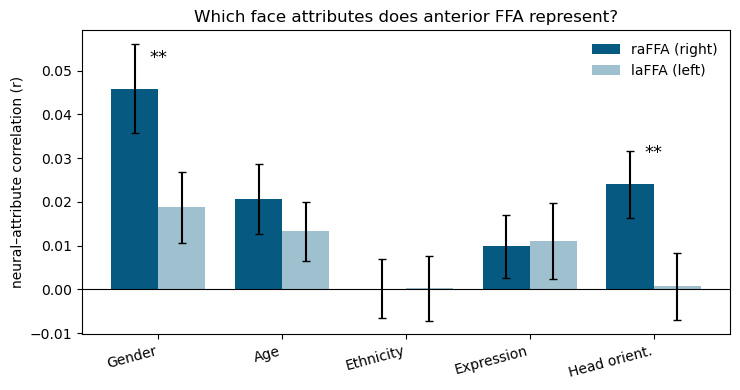

saved: /home/jovyan/heather_analysis/figures/attribute_hemisphere.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

D = "/home/jovyan/face_DCNN/data"
FIG = "/home/jovyan/heather_analysis/figures"
os.makedirs(FIG, exist_ok=True)

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    n = 58 if run == 11 else 59
    s = slice(run*59, run*59 + n)
    return squareform(m[s][:, s])

features = ["perceived_gender","age","ethnicity","expression","head_orientation"]

out = {}
for roi in ["raFFA","laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy")
    out[roi] = {}
    for feat in features:
        masks = np.load(f"{D}/feature_masks/{feat}_masks.npy", allow_pickle=True)
        rs = []
        for run in range(12):
            model = 1.0 - np.asarray(masks[run], dtype=float)
            neu = np.stack([single_run(s, run) for s in neural]).mean(axis=0)
            if len(model) == len(neu):
                rs.append(pearsonr(model, neu)[0])
        out[roi][feat] = np.array(rs)

# ---- figure ----
labels = ["Gender","Age","Ethnicity","Expression","Head orient."]
ra   = [out["raFFA"][f].mean() for f in features]
la   = [out["laFFA"][f].mean() for f in features]
rase = [out["raFFA"][f].std(ddof=1)/np.sqrt(len(out["raFFA"][f])) for f in features]
lase = [out["laFFA"][f].std(ddof=1)/np.sqrt(len(out["laFFA"][f])) for f in features]

x = np.arange(len(features)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5,4))
ax.bar(x-w/2, ra, w, yerr=rase, capsize=3, label="raFFA (right)", color="#065A82")
ax.bar(x+w/2, la, w, yerr=lase, capsize=3, label="laFFA (left)",  color="#9FC0CE")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("neural–attribute correlation (r)")
ax.set_title("Which face attributes does anterior FFA represent?")
ax.legend(frameon=False)
for i, f in enumerate(features):
    if f in ("perceived_gender","head_orientation"):
        ax.text(i, max(ra[i], la[i]) + 0.006, "**", ha="center", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG}/attribute_hemisphere.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", f"{FIG}/attribute_hemisphere.png")

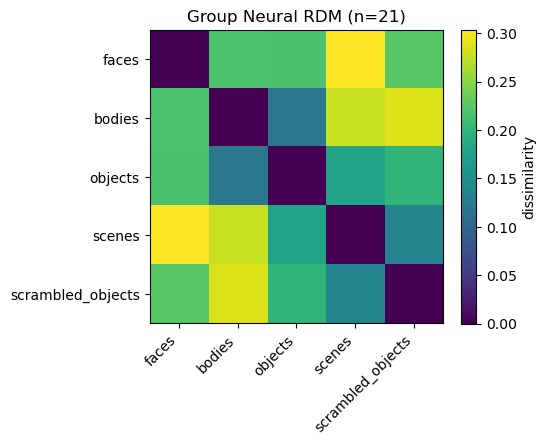

Animacy                r=+0.325  t=6.42  p=2.93e-06
Face-selective         r=+0.230  t=3.65  p=1.58e-03
Object vs scene        r=+0.437  t=7.05  p=7.70e-07
Intact vs scrambled    r=-0.017  t=-0.42  p=6.80e-01


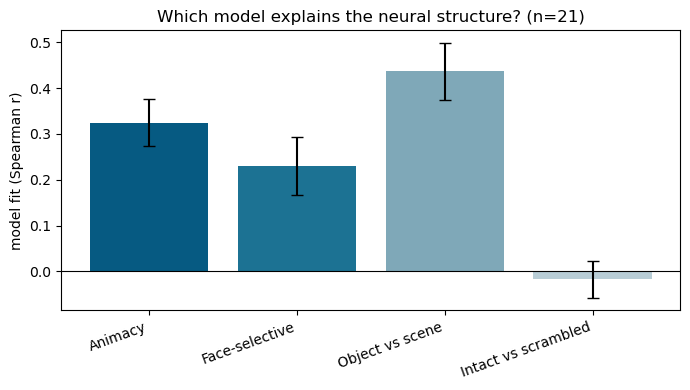

/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


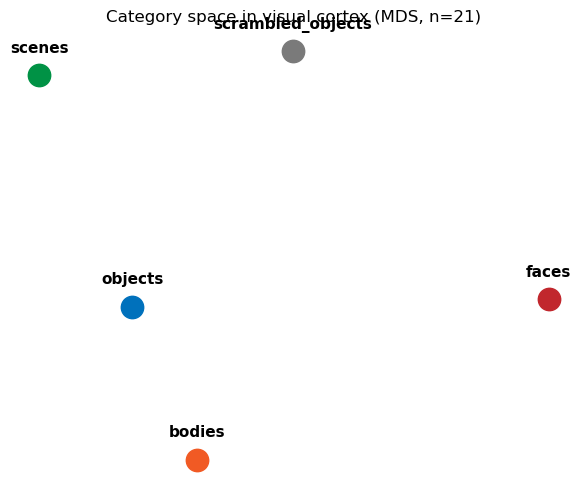

raFFA: r=0.046  ceiling=0.361  = 12.8% of ceiling
laFFA: r=0.026  ceiling=0.331  = 7.8% of ceiling


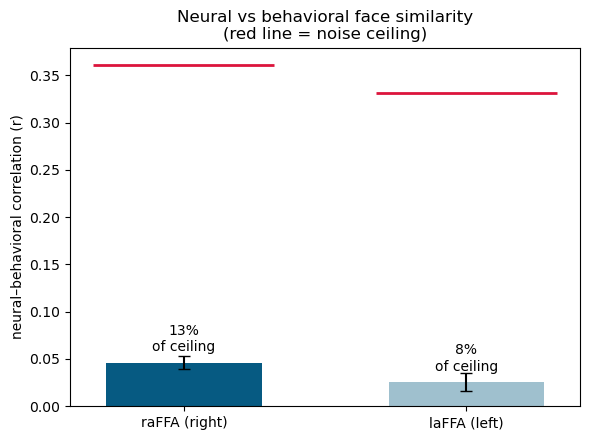

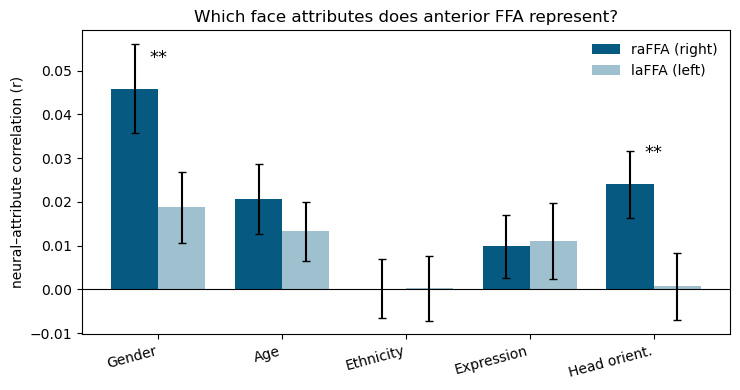


Saved: ['.ipynb_checkpoints', '1_group_rdm.png', '2_model_comparison.png', '3_mds.png', '4_neural_behavioral.png', '5_attribute_hemisphere.png', 'attribute_hemisphere.png']


In [5]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, pearsonr, ttest_1samp
from sklearn.manifold import MDS

FIG = "/home/jovyan/heather_analysis/figures"; os.makedirs(FIG, exist_ok=True)
D = "/home/jovyan/face_DCNN/data"
categories = ["faces","bodies","objects","scenes","scrambled_objects"]

# ============ FIG 1 & 2 & 3: localizer (from saved RDMs) ============
rdms = np.load("/home/jovyan/heather_analysis/hyperface_rdms.npy", allow_pickle=True).item()
subs = sorted(rdms.keys()); iu = np.triu_indices(5, k=1)
group_rdm = np.stack([rdms[s] for s in subs]).mean(axis=0)

# FIG 1: group RDM
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(group_rdm, cmap="viridis")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(categories, rotation=45, ha="right"); ax.set_yticklabels(categories)
ax.set_title(f"Group Neural RDM (n={len(subs)})")
plt.colorbar(im, label="dissimilarity"); plt.tight_layout()
plt.savefig(f"{FIG}/1_group_rdm.png", dpi=200, bbox_inches="tight"); plt.show()

# FIG 2: model comparison
def mfg(g): g=np.array(g); return (g[:,None]!=g[None,:]).astype(float)
models = {"Animacy":mfg([1,1,0,0,0]), "Face-selective":mfg([1,0,0,0,0]),
          "Object vs scene":mfg([0,0,0,1,1]), "Intact vs scrambled":mfg([0,0,0,0,1])}
res = {}
for nm,m in models.items():
    rs = np.array([spearmanr(rdms[s][iu], m[iu]).statistic for s in subs])
    res[nm] = rs
    t,p = ttest_1samp(rs,0); print(f"{nm:<22} r={rs.mean():+.3f}  t={t:.2f}  p={p:.2e}")

names = list(res); means=[res[n].mean() for n in names]
sems=[res[n].std(ddof=1)/np.sqrt(len(subs)) for n in names]
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(names, means, yerr=sems, capsize=4, color=["#065A82","#1C7293","#7FA8B8","#B8CDD6"])
ax.axhline(0,color="k",lw=.8); ax.set_ylabel("model fit (Spearman r)")
ax.set_title(f"Which model explains the neural structure? (n={len(subs)})")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(f"{FIG}/2_model_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

# FIG 3: MDS
coords = MDS(n_components=2, dissimilarity="precomputed", random_state=0,
             normalized_stress="auto").fit_transform(group_rdm)
colors = {"faces":"#C1272D","bodies":"#F15A24","objects":"#0071BC",
          "scenes":"#009245","scrambled_objects":"#7A7A7A"}
fig, ax = plt.subplots(figsize=(6,5))
for (x,y),c in zip(coords, categories):
    ax.scatter(x,y,s=260,color=colors[c],zorder=3)
    ax.annotate(c,(x,y),textcoords="offset points",xytext=(0,16),ha="center",
                fontsize=11,weight="bold")
ax.set_title(f"Category space in visual cortex (MDS, n={len(subs)})")
ax.set_xticks([]); ax.set_yticks([])
ax.spines[["top","right","left","bottom"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{FIG}/3_mds.png", dpi=200, bbox_inches="tight"); plt.show()

# ============ FIG 4 & 5: hyperface ============
def single_run(full, run):
    m = squareform(full); n = 58 if run==11 else 59
    s = slice(run*59, run*59+n); return squareform(m[s][:,s])

def cronbach(x):
    k=x.shape[0]; return (k/(k-1))*(1 - x.var(axis=1,ddof=1).sum()/x.sum(axis=0).var(ddof=1))

# FIG 4: neural-behavioral % of ceiling
pct = {}
for roi in ["raFFA","laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy"); rs=[]; cs=[]
    for run in range(12):
        b = np.load(f"{D}/behavioral_RDMs/{run:02d}.npy").mean(axis=0)
        ps = np.stack([single_run(s,run) for s in neural])
        rs.append(pearsonr(b, ps.mean(axis=0))[0]); cs.append(cronbach(ps))
    pct[roi] = (np.array(rs), np.array(cs))
    print(f"{roi}: r={np.mean(rs):.3f}  ceiling={np.mean(cs):.3f}  = {100*np.mean(rs)/np.mean(cs):.1f}% of ceiling")

fig, ax = plt.subplots(figsize=(6,4.5))
for i,roi in enumerate(["raFFA","laFFA"]):
    r,c = pct[roi]
    ax.bar(i, r.mean(), 0.55, yerr=r.std(ddof=1)/np.sqrt(12), capsize=4,
           color=["#065A82","#9FC0CE"][i])
    ax.hlines(c.mean(), i-.32, i+.32, color="crimson", lw=2)
    ax.text(i, r.mean()+0.012, f"{100*r.mean()/c.mean():.0f}%\nof ceiling",
            ha="center", fontsize=10)
ax.set_xticks([0,1]); ax.set_xticklabels(["raFFA (right)","laFFA (left)"])
ax.set_ylabel("neural–behavioral correlation (r)")
ax.set_title("Neural vs behavioral face similarity\n(red line = noise ceiling)")
plt.tight_layout(); plt.savefig(f"{FIG}/4_neural_behavioral.png", dpi=200, bbox_inches="tight"); plt.show()

# FIG 5: attribute x hemisphere
features = ["perceived_gender","age","ethnicity","expression","head_orientation"]
labels = ["Gender","Age","Ethnicity","Expression","Head orient."]
out = {}
for roi in ["raFFA","laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy"); out[roi]={}
    for f in features:
        masks = np.load(f"{D}/feature_masks/{f}_masks.npy", allow_pickle=True)
        rs=[]
        for run in range(12):
            model = 1.0-np.asarray(masks[run],dtype=float)
            neu = np.stack([single_run(s,run) for s in neural]).mean(axis=0)
            if len(model)==len(neu): rs.append(pearsonr(model,neu)[0])
        out[roi][f]=np.array(rs)

ra=[out["raFFA"][f].mean() for f in features]; la=[out["laFFA"][f].mean() for f in features]
rae=[out["raFFA"][f].std(ddof=1)/np.sqrt(12) for f in features]
lae=[out["laFFA"][f].std(ddof=1)/np.sqrt(12) for f in features]
x=np.arange(5); w=.38
fig, ax = plt.subplots(figsize=(7.5,4))
ax.bar(x-w/2, ra, w, yerr=rae, capsize=3, label="raFFA (right)", color="#065A82")
ax.bar(x+w/2, la, w, yerr=lae, capsize=3, label="laFFA (left)", color="#9FC0CE")
ax.axhline(0,color="k",lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("neural–attribute correlation (r)")
ax.set_title("Which face attributes does anterior FFA represent?")
ax.legend(frameon=False)
for i,f in enumerate(features):
    if f in ("perceived_gender","head_orientation"):
        ax.text(i, max(ra[i],la[i])+0.006, "**", ha="center", fontsize=13)
plt.tight_layout(); plt.savefig(f"{FIG}/5_attribute_hemisphere.png", dpi=200, bbox_inches="tight"); plt.show()

print("\nSaved:", sorted(os.listdir(FIG)))

/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


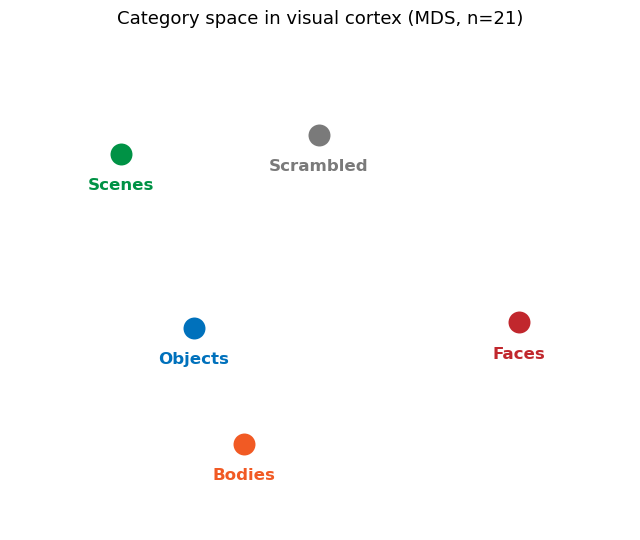

In [7]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.manifold import MDS

FIG = "/home/jovyan/heather_analysis/figures"
categories = ["faces","bodies","objects","scenes","scrambled_objects"]
rdms = np.load("/home/jovyan/heather_analysis/hyperface_rdms.npy", allow_pickle=True).item()
subs = sorted(rdms.keys())
group_rdm = np.stack([rdms[s] for s in subs]).mean(axis=0)

coords = MDS(n_components=2, dissimilarity="precomputed", random_state=0,
             normalized_stress="auto").fit_transform(group_rdm)

nice = {"faces":"Faces","bodies":"Bodies","objects":"Objects",
        "scenes":"Scenes","scrambled_objects":"Scrambled"}
colors = {"faces":"#C1272D","bodies":"#F15A24","objects":"#0071BC",
          "scenes":"#009245","scrambled_objects":"#7A7A7A"}

fig, ax = plt.subplots(figsize=(6.5,5.5))
for (x,y),c in zip(coords, categories):
    ax.scatter(x, y, s=300, color=colors[c], zorder=3, edgecolors="white", linewidth=1.5)
    ax.annotate(nice[c], (x,y), textcoords="offset points", xytext=(0,-26),
                ha="center", fontsize=12, weight="bold", color=colors[c])

# pad so nothing sits on the edge
xs, ys = coords[:,0], coords[:,1]
padx = (xs.max()-xs.min())*0.28 or 0.1
pady = (ys.max()-ys.min())*0.28 or 0.1
ax.set_xlim(xs.min()-padx, xs.max()+padx)
ax.set_ylim(ys.min()-pady, ys.max()+pady)

ax.set_title("Category space in visual cortex (MDS, n=21)", fontsize=13, pad=18)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG}/3_mds.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map

clean_map, thr = threshold_stats_img(
    z_faces_vs_objects, alpha=0.05, height_control="fdr", cluster_threshold=20)
print(f"FDR threshold: z = {thr:.2f}")

plot_stat_map(clean_map, threshold=thr,
              title="faces > objects (FDR q<.05, k≥20), sub-005",
              display_mode="z", cut_coords=[-29, -20, -14, -8],
              output_file="/home/jovyan/heather_analysis/figures/6_faces_vs_objects_clean.png")

FDR threshold: z = 3.32


In [9]:
from nilearn.image import mean_img
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map

# background in the SAME space as the stat map
bg = mean_img(bold)     # or the boldref: ..._space-T1w_boldref.nii.gz

clean_map, thr = threshold_stats_img(
    z_faces_vs_objects, alpha=0.05, height_control="fdr", cluster_threshold=20)

plot_stat_map(clean_map, bg_img=bg, threshold=thr,
              title="faces > objects (FDR q<.05, k≥20), sub-005",
              display_mode="z", cut_coords=[-29, -20, -14, -8],
              output_file="/home/jovyan/heather_analysis/figures/6_faces_vs_objects_final.png")

In [16]:
from nilearn.image import mean_img
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map

FIG = "/home/jovyan/heather_analysis/figures"
deriv = "/home/jovyan/hyperface/ds007384/sub-sid000005/ses-1/func"

# background in the same space as the stat map
bg = ("/home/jovyan/hyperface/ds007384/sub-sid000005/ses-budapest/anat/"
      "sub-sid000005_ses-budapest_acq-MPRAGE_desc-preproc_T1w.nii.gz")

clean_map, thr = threshold_stats_img(
    z_faces_vs_objects, alpha=0.05, height_control="fdr", cluster_threshold=20)
print(f"FDR threshold: z = {thr:.2f}")

plot_stat_map(clean_map,
              bg_img=bg,
              threshold=thr,
              title="faces > objects (FDR q<.05, k>=20), sub-005",
              display_mode="z",
              cut_coords=[-29, -20, -14, -8],
              output_file=f"{FIG}/6_faces_vs_objects_final.png")
print("saved")

FDR threshold: z = 3.32
saved


In [13]:
import os
print([f for f in os.listdir(deriv) if "run-01" in f and "localizer" in f])

['sub-sid000005_ses-1_task-localizer_run-01_desc-brain_mask.json', 'sub-sid000005_ses-1_task-localizer_run-01_desc-brain_mask.nii.gz', 'sub-sid000005_ses-1_task-localizer_run-01_desc-confounds_timeseries.json', 'sub-sid000005_ses-1_task-localizer_run-01_desc-confounds_timeseries.tsv', 'sub-sid000005_ses-1_task-localizer_run-01_desc-coreg_boldref.json', 'sub-sid000005_ses-1_task-localizer_run-01_desc-coreg_boldref.nii.gz', 'sub-sid000005_ses-1_task-localizer_run-01_desc-hmc_boldref.json', 'sub-sid000005_ses-1_task-localizer_run-01_desc-hmc_boldref.nii.gz', 'sub-sid000005_ses-1_task-localizer_run-01_from-boldref_to-T1w_mode-image_desc-coreg_xfm.json', 'sub-sid000005_ses-1_task-localizer_run-01_from-boldref_to-T1w_mode-image_desc-coreg_xfm.txt', 'sub-sid000005_ses-1_task-localizer_run-01_from-boldref_to-auto00000_mode-image_xfm.json', 'sub-sid000005_ses-1_task-localizer_run-01_from-boldref_to-auto00000_mode-image_xfm.txt', 'sub-sid000005_ses-1_task-localizer_run-01_from-orig_to-boldref_mo

In [14]:
import os, re
files = os.listdir(deriv)
print("spaces present:", sorted(set(re.findall(r"space-[A-Za-z0-9]+", " ".join(files)))))
print("\nanat dir exists:", os.path.isdir("/home/jovyan/hyperface/ds007384/sub-sid000005/anat"))

spaces present: ['space-T1w', 'space-fsaverage6']

anat dir exists: False


In [17]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, ttest_1samp, ttest_rel

D = "/home/jovyan/face_DCNN/data"

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    n = 58 if run == 11 else 59
    s = slice(run*59, run*59 + n)
    return squareform(m[s][:, s])

# precompute the 12 behavioral RDMs
behav = [np.load(f"{D}/behavioral_RDMs/{r:02d}.npy").mean(axis=0) for r in range(12)]

per_subject = {}
for roi in ["raFFA", "laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy")     # (21, 249571)
    subj_r = []
    for s in range(neural.shape[0]):                        # each subject
        rs = []
        for run in range(12):
            n_run = single_run(neural[s], run)
            if len(n_run) == len(behav[run]):
                rs.append(pearsonr(behav[run], n_run)[0])
        subj_r.append(np.mean(rs))                          # avg across runs
    subj_r = np.array(subj_r)
    per_subject[roi] = subj_r
    t, p = ttest_1samp(subj_r, 0)
    print(f"{roi}: mean r = {subj_r.mean():+.4f}  (SD {subj_r.std(ddof=1):.4f})")
    print(f"       t(20) = {t:.2f}, p = {p:.2e}   [{np.sum(subj_r>0)}/21 subjects positive]")

# hemispheric comparison, now across subjects
t, p = ttest_rel(per_subject["raFFA"], per_subject["laFFA"])
print(f"\nraFFA vs laFFA across subjects: t(20) = {t:.2f}, p = {p:.4f}")

raFFA: mean r = +0.0120  (SD 0.0095)
       t(20) = 5.81, p = 1.10e-05   [19/21 subjects positive]
laFFA: mean r = +0.0067  (SD 0.0089)
       t(20) = 3.41, p = 2.77e-03   [17/21 subjects positive]

raFFA vs laFFA across subjects: t(20) = 1.92, p = 0.0687


In [18]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, ttest_1samp, ttest_rel

D = "/home/jovyan/face_DCNN/data"
features = ["perceived_gender","age","ethnicity","expression","head_orientation"]

def single_run(full_rdm, run):
    m = squareform(full_rdm)
    n = 58 if run == 11 else 59
    s = slice(run*59, run*59 + n)
    return squareform(m[s][:, s])

masks = {f: np.load(f"{D}/feature_masks/{f}_masks.npy", allow_pickle=True) for f in features}

subj = {}
for roi in ["raFFA","laFFA"]:
    neural = np.load(f"{D}/neural_RDMs/{roi}_RDMs.npy")
    subj[roi] = {}
    for f in features:
        vals = []
        for s in range(neural.shape[0]):          # per subject
            rs = []
            for run in range(12):
                model = 1.0 - np.asarray(masks[f][run], dtype=float)
                n_run = single_run(neural[s], run)
                if len(model) == len(n_run):
                    rs.append(pearsonr(model, n_run)[0])
            vals.append(np.mean(rs))              # avg across runs
        subj[roi][f] = np.array(vals)

print(f"{'feature':>18} {'ROI':>7} {'mean r':>9} {'t(20)':>7} {'p':>10}")
for f in features:
    for roi in ["raFFA","laFFA"]:
        v = subj[roi][f]; t,p = ttest_1samp(v, 0)
        print(f"{f:>18} {roi:>7} {v.mean():>+9.4f} {t:>7.2f} {p:>10.2e}")

print("\n--- Right vs Left, across 21 subjects ---")
for f in features:
    t,p = ttest_rel(subj["raFFA"][f], subj["laFFA"][f])
    star = "**" if p < .01 else ("*" if p < .05 else "")
    print(f"{f:>18}: {subj['raFFA'][f].mean():+.4f} vs {subj['laFFA'][f].mean():+.4f}  t(20)={t:+.2f}, p={p:.4f} {star}")

           feature     ROI    mean r   t(20)          p
  perceived_gender   raFFA   +0.0116    5.56   1.90e-05
  perceived_gender   laFFA   +0.0051    3.43   2.63e-03
               age   raFFA   +0.0058    3.96   7.72e-04
               age   laFFA   +0.0034    1.98   6.13e-02
         ethnicity   raFFA   -0.0000   -0.02   9.83e-01
         ethnicity   laFFA   +0.0002    0.15   8.83e-01
        expression   raFFA   +0.0023    1.70   1.05e-01
        expression   laFFA   +0.0027    1.99   6.08e-02
  head_orientation   raFFA   +0.0065    3.18   4.65e-03
  head_orientation   laFFA   -0.0000   -0.02   9.83e-01

--- Right vs Left, across 21 subjects ---
  perceived_gender: +0.0116 vs +0.0051  t(20)=+2.11, p=0.0479 *
               age: +0.0058 vs +0.0034  t(20)=+1.34, p=0.1941 
         ethnicity: -0.0000 vs +0.0002  t(20)=-0.16, p=0.8766 
        expression: +0.0023 vs +0.0027  t(20)=-0.24, p=0.8114 
  head_orientation: +0.0065 vs -0.0000  t(20)=+3.23, p=0.0042 **
